# Voice Cloning (Part 1)

Runnable version of Part 1 of `voice_cloning_and_fake_audio_detection.ipynb`, using TIMIT (Kaggle copy) and the pretrained SV2TTS models in `WebApp/saved_models/default`.

Changes from the original:
- TIMIT audio is read from the converted `*.WAV.wav` files (the `.WAV` files are NIST SPHERE)
- `audio_3` is defined, and file paths work on macOS/Linux
- Sentence ids such as `(sa1)` are stripped from the TIMIT prompts
- Only `N_SPEAKERS` speakers are cloned in the final step (each clone takes about a minute on CPU; all 630 would take many hours)
- Cloned files go to `data/cloned_audio` so they don't mix with the Part 2 stand-in data

The WER cells send audio to Google's free speech recognition API, so they need internet access. Markdown commentary with numbers is from the original run.

# Voice Cloning and Fake Audio Detection

### Introduction
A technology company working in the Cyber Security industry wants to build data driven systems that help individuals and organizations to understand whether audio and video media is authentic or fake.


### Data Description:

Two datasets will be used in this project:

[**TIMIT Dataset:**](https://github.com/philipperemy/timit) The TIMIT corpus of read speech is designed to provide speech data for acoustic-phonetic studies and for the development and evaluation of automatic speech recognition systems. TIMIT contains a total of 6300 sentences, 10 sentences spoken by each of 630 speakers from 8 major dialect regions of the United States.

[**CommonVoice Dataset:**](https://commonvoice.mozilla.org/en/datasets) Common Voice is part of Mozilla's initiative to help teach machines how real people speak. Common Voice is a corpus of speech data read by users on the [Common Voice website](https://commonvoice.mozilla.org/), and based upon text from a number of public domain sources like user submitted blog posts, old books, movies, and other public speech corpora. Its primary purpose is to enable the training and testing of automatic speech recognition (ASR) systems.

### Goals(s):
The goal of this project is to build algorithms that can synthesize spoken audio by converting a speaker’s voice to another speaker’s voice with the end goal to detect if any spoken audio is pristine or fake.

### Success Metrics:
* **Voice cloning (VC):** Word Error Rate (WER)
* **Fake audio detection (FAD):** F-score

### Methodology:
**Step 1:** We will build a **Voice Cloning system (VC)** that clones source speaker's voice to the target speaker's voice. We will utlize the TIMIT dataset for this step as it consists of aligned text-audio data with various speakers.

**Step 2:** We will build a **Fake audio detection system (FAD)** that detects if a given audio is synthetically generated or not. We will utilize the CommonVoice dataset as it consists of thousands of naturally spoken audio which could be used as positive examples and creating negative examples using the voice cloning system as automatic data/label generator.

## Part 1: Voice Cloning

As mentioned above, the TIMIT dataset contains 10 recordings from 630 different speakers. All the audio files (4s) are recordings of short sentences from different users. For our Voice cloning system, we will use SV2TTS deep learning framework which is effective in converting text to speech. The framework is made of 3 stages. In the first stage, one creates a digital representation of a voice from a few seconds of audio. In the second and third stages, this representation is used as reference to generate speech given arbitrary text. We will evaluate the performance of the voice cloning system by performing the following experiments. 

We will use the following github repo (https://github.com/CorentinJ/Real-Time-Voice-Cloning.git) for the voice cloning system

**Exp 1:** We will utilize the short recordings from the TIMIT dataset to generate short and long audios and evaluate the perfromance of the model.

**Exp 2:** We will combine the recordings from similar users and use that to generate short and synthetic audios and evaluate the model's perfromance.


### Initial Setup
Import relevant libraries and install the voice cloning model from the github repo

In [1]:
import os
import re
from pathlib import Path
import librosa
import librosa.display
import pandas as pd
import functions
import numpy as np
from IPython.display import display, Audio, clear_output
from moviepy.editor import concatenate_audioclips, AudioFileClip
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

N_SPEAKERS = 10  # number of speakers cloned in the final step (630 in the original run)

for d in ['cloned_data', 'data/long_version_audio', 'data/cloned_audio']:
    os.makedirs(d, exist_ok=True)

The following cells contain information about the recordings from the TIMIT dataset

In [2]:
train_csv = pd.read_csv("TIMIT_orig/DOC/train_data.csv")
print(train_csv.shape)
train_csv.head()

(31678, 12)


,index,test_or_train,dialect_region,speaker_id,filename,path_from_data_dir,path_from_data_dir_windows,is_converted_audio,is_audio,is_word_file,is_phonetic_file,is_sentence_file
0,1.0,TRAIN,DR4,MMDM0,SI681.WAV.wav,TRAIN/DR4/MMDM0/SI681.WAV.wav,TRAIN\\DR4\\MMDM0\\SI681.WAV.wav,True,True,False,False,False
1,2.0,TRAIN,DR4,MMDM0,SI1311.PHN,TRAIN/DR4/MMDM0/SI1311.PHN,TRAIN\\DR4\\MMDM0\\SI1311.PHN,False,False,False,True,False
2,3.0,TRAIN,DR4,MMDM0,SI1311.WRD,TRAIN/DR4/MMDM0/SI1311.WRD,TRAIN\\DR4\\MMDM0\\SI1311.WRD,False,False,True,False,False
3,4.0,TRAIN,DR4,MMDM0,SX321.PHN,TRAIN/DR4/MMDM0/SX321.PHN,TRAIN\\DR4\\MMDM0\\SX321.PHN,False,False,False,True,False
4,5.0,TRAIN,DR4,MMDM0,SX321.WRD,TRAIN/DR4/MMDM0/SX321.WRD,TRAIN\\DR4\\MMDM0\\SX321.WRD,False,False,True,False,False


In [3]:
test_csv = pd.read_csv("TIMIT_orig/DOC/test_data.csv")
print(test_csv.shape)
test_csv.head()

(31678, 12)


,index,test_or_train,dialect_region,speaker_id,filename,path_from_data_dir,path_from_data_dir_windows,is_converted_audio,is_audio,is_word_file,is_phonetic_file,is_sentence_file
0,1.0,TEST,DR4,MGMM0,SX139.WAV,TEST/DR4/MGMM0/SX139.WAV,TEST\\DR4\\MGMM0\\SX139.WAV,False,True,False,False,False
1,2.0,TEST,DR4,MGMM0,SX139.WAV.wav,TEST/DR4/MGMM0/SX139.WAV.wav,TEST\\DR4\\MGMM0\\SX139.WAV.wav,True,True,False,False,False
2,3.0,TEST,DR4,MGMM0,SX139.TXT,TEST/DR4/MGMM0/SX139.TXT,TEST\\DR4\\MGMM0\\SX139.TXT,False,False,False,False,True
3,4.0,TEST,DR4,MGMM0,SI499.WRD,TEST/DR4/MGMM0/SI499.WRD,TEST\\DR4\\MGMM0\\SI499.WRD,False,False,True,False,False
4,5.0,TEST,DR4,MGMM0,SX319.WRD,TEST/DR4/MGMM0/SX319.WRD,TEST\\DR4\\MGMM0\\SX319.WRD,False,False,True,False,False


The following texts will be used to genrate the synthetic audio files

In [4]:
long_text = """Two roads diverged in a yellow wood,
And sorry I could not travel both 
And be one traveler, long I stood
And looked down one as far as I could
To where it bent in the undergrowth;""".replace('\n',' ')

short_text = "If you're looking for random paragraphs, you've come to the right place"

We will display random samples from the TIMIT dataset

In [5]:
audio_1, sample_rate = librosa.load('TIMIT_orig/TRAIN/DR4/FLHD0/SA1.WAV.wav')
display(Audio(audio_1, autoplay=True, rate=sample_rate))

[Audio player removed: TIMIT recordings are licensed and not redistributed here. Re-run the cell with TIMIT to listen.]


In [6]:
audio_2, sample_rate = librosa.load('TIMIT_orig/TRAIN/DR1/MCPM0/SA2.WAV.wav')
display(Audio(audio_2, autoplay=True, rate=sample_rate))

[Audio player removed: TIMIT recordings are licensed and not redistributed here. Re-run the cell with TIMIT to listen.]


In [7]:
audio_3, sample_rate = librosa.load('TIMIT_orig/TRAIN/DR5/MDSJ0/SA1.WAV.wav')
display(Audio(audio_3, rate=sample_rate))

[Audio player removed: TIMIT recordings are licensed and not redistributed here. Re-run the cell with TIMIT to listen.]


#### Exp - 1.1: 
In the following section, we will use the short recordings from the TIMIT dataset to generate the synthetic audios for short texts.

In [8]:
functions.synthesize_audio(audio_1, short_text, 'cloned_data/exp-1-1.wav')
functions.synthesize_audio(audio_2, short_text, 'cloned_data/exp-1-2.wav')
functions.synthesize_audio(audio_3, short_text, 'cloned_data/exp-1-3.wav')

In [9]:
display(Audio('cloned_data/exp-1-1.wav', autoplay=True))

In [10]:
display(Audio('cloned_data/exp-1-2.wav', autoplay=True))

In [11]:
sim_score11, wer11 = functions.text_comparison('cloned_data/exp-1-1.wav', short_text)
sim_score12, wer12 = functions.text_comparison('cloned_data/exp-1-2.wav', short_text)
sim_score13, wer13 = functions.text_comparison('cloned_data/exp-1-3.wav', short_text)

print("WER for the cloned audio: ", (wer11, wer12, wer13))
print("Mean WER: ", np.mean([wer11, wer12, wer13])*100)
print("Similarity scores for the cloned audio: ", (sim_score11, sim_score12, sim_score13))

cloned_text:  if you're looking for random paragraphs you've come to the right place
original_text:  If you're looking for random paragraphs, you've come to the right place
####################################################################


cloned_text:  if you're looking for random paragraphs you've come to the right place
original_text:  If you're looking for random paragraphs, you've come to the right place
####################################################################


cloned_text:  if you're looking for random paragraphs you've come to the right place
original_text:  If you're looking for random paragraphs, you've come to the right place
####################################################################
WER for the cloned audio:  (0.08333333333333333, 0.08333333333333333, 0.08333333333333333)
Mean WER:  8.333333333333332
Similarity scores for the cloned audio:  (0.9449431423265419, 0.9449431423265419, 0.9449431423265419)


#### Exp - 1.2: 
In the following section, we will use the short recordings from the TIMIT dataset to generate the synthetic audios for long texts.

In [12]:
functions.synthesize_audio(audio_1, long_text, 'cloned_data/exp-2-1.wav')
functions.synthesize_audio(audio_2, long_text, 'cloned_data/exp-2-2.wav')
functions.synthesize_audio(audio_3, long_text, 'cloned_data/exp-2-3.wav')

In [13]:
display(Audio('cloned_data/exp-2-1.wav', autoplay=True))

In [14]:
display(Audio('cloned_data/exp-2-3.wav', autoplay=True))

In [15]:
sim_score21, wer21 = functions.text_comparison('cloned_data/exp-2-1.wav', long_text)
sim_score22, wer22 = functions.text_comparison('cloned_data/exp-2-2.wav', long_text)
sim_score23, wer23 = functions.text_comparison('cloned_data/exp-2-3.wav', long_text)

print("WER for the cloned audio: ", (wer21, wer22, wer23))
print("Mean WER: ", np.mean([wer21, wer22, wer23])*100)
print("Similarity scores for the cloned audio: ", (sim_score21, sim_score22, sim_score23))

cloned_text:  two roads diverged in a yellow wood and sorry I could not travel both and be one traveler all my stuff and look down well as far as I could to wear it in the underwear
original_text:  Two roads diverged in a yellow wood, And sorry I could not travel both  And be one traveler, long I stood And looked down one as far as I could To where it bent in the undergrowth;
####################################################################


cloned_text:  two roads diverged in a yellow wood and sorry I could not travel both and be one traveler while I stood and looked down one as far as I could do it then
original_text:  Two roads diverged in a yellow wood, And sorry I could not travel both  And be one traveler, long I stood And looked down one as far as I could To where it bent in the undergrowth;
####################################################################


cloned_text:  two roads diverged in a yellow wood and sorry I could not travel both would be one traveler long distance and looked down one as far as I could to wear that in the underground
original_text:  Two roads diverged in a yellow wood, And sorry I could not travel both  And be one traveler, long I stood And looked down one as far as I could To where it bent in the undergrowth;
####################################################################
WER for the cloned audio:  (0.2702702702702703, 0.24324324324324326, 0.24324324324324326)
Mean WER:  25.225225225225227
Similarity scores for the cloned audio:  (0.7319101512222239, 0.8289867933996871, 0.7839410339696848)


Results from exp 1-2 are much worse than the results from exp 1-1 with 58% Word Error Rate. This is because, it is difficult to generate long audio files from short sample and the rest of the words could not be synthesised

For the next part of the experiments, we will combine recoedings from the same speakers in the TIMIT dataset into a single file (30s). There are 6300 recordings from 630 speakers. We will generate 630 audio files by combining these recordings from the same speakers.

In [16]:
# This dictionary saves paths of all the recordings from the same speaker under a single key
my_dict = {}
for split in ['TIMIT_orig/TRAIN', 'TIMIT_orig/TEST']:
    for file_path in sorted(Path(split).glob('*/*/*.WAV.wav')):
        my_dict.setdefault(file_path.parent.name, []).append(str(file_path))

print(len(my_dict))
print(list(my_dict.items())[0])

630
('FCJF0', ['TIMIT_orig/TRAIN/DR1/FCJF0/SA1.WAV.wav', 'TIMIT_orig/TRAIN/DR1/FCJF0/SA2.WAV.wav', 'TIMIT_orig/TRAIN/DR1/FCJF0/SI1027.WAV.wav', 'TIMIT_orig/TRAIN/DR1/FCJF0/SI1657.WAV.wav', 'TIMIT_orig/TRAIN/DR1/FCJF0/SI648.WAV.wav', 'TIMIT_orig/TRAIN/DR1/FCJF0/SX127.WAV.wav', 'TIMIT_orig/TRAIN/DR1/FCJF0/SX217.WAV.wav', 'TIMIT_orig/TRAIN/DR1/FCJF0/SX307.WAV.wav', 'TIMIT_orig/TRAIN/DR1/FCJF0/SX37.WAV.wav', 'TIMIT_orig/TRAIN/DR1/FCJF0/SX397.WAV.wav'])


Concatenate the audio files from the same speakers into a single file 

In [17]:
functions.concat_audio(my_dict['MWDK0'], 'cloned_data/long-audio-1.wav')
functions.concat_audio(my_dict['FGRW0'], 'cloned_data/long-audio-2.wav')
functions.concat_audio(my_dict['MSAT1'], 'cloned_data/long-audio-3.wav')

MoviePy - Writing audio in cloned_data/long-audio-1.wav


chunk:   0%|          | 0/661 [00:00<?, ?it/s, now=None]

chunk:  13%|█▎        | 85/661 [00:00<00:00, 849.50it/s, now=None]

chunk:  33%|███▎      | 221/661 [00:00<00:00, 1146.61it/s, now=None]

chunk:  51%|█████     | 336/661 [00:00<00:00, 1052.22it/s, now=None]

...

chunk:  43%|████▎     | 280/653 [00:00<00:00, 726.24it/s, now=None]

chunk:  57%|█████▋    | 371/653 [00:00<00:00, 787.06it/s, now=None]

chunk:  74%|███████▍  | 485/653 [00:00<00:00, 901.08it/s, now=None]

chunk:  88%|████████▊ | 577/653 [00:00<00:00, 877.41it/s, now=None]

MoviePy - Done.


In [18]:
display(Audio('cloned_data/long-audio-1.wav', autoplay=True))

[Audio player removed: TIMIT recordings are licensed and not redistributed here. Re-run the cell with TIMIT to listen.]


#### Exp - 2.1: 
In the following section, we will use the long recordings from the TIMIT dataset to generate the synthetic audios for short texts.

In [19]:
functions.synthesize_audio('cloned_data/long-audio-1.wav', short_text, 'cloned_data/exp-3-1.wav')
functions.synthesize_audio('cloned_data/long-audio-2.wav', short_text, 'cloned_data/exp-3-2.wav')
functions.synthesize_audio('cloned_data/long-audio-3.wav', short_text, 'cloned_data/exp-3-3.wav')

In [20]:
display(Audio('cloned_data/exp-3-1.wav', autoplay=True))

In [21]:
display(Audio('cloned_data/exp-3-2.wav', autoplay=True))

In [22]:
sim_score31, wer31 = functions.text_comparison('cloned_data/exp-3-1.wav', short_text)
sim_score32, wer32 = functions.text_comparison('cloned_data/exp-3-2.wav', short_text)
sim_score33, wer33 = functions.text_comparison('cloned_data/exp-3-3.wav', short_text)

print("WER for the cloned audio: ", (wer31, wer32, wer33))
print("Mean WER: ", np.mean([wer31, wer32, wer33])*100)
print("Similarity scores for the cloned audio: ", (sim_score31, sim_score32, sim_score33))

cloned_text:  if you're looking for a random paragraph you've come to the right place
original_text:  If you're looking for random paragraphs, you've come to the right place
####################################################################


cloned_text:  if you're looking for random paragraph come to the right place
original_text:  If you're looking for random paragraphs, you've come to the right place
####################################################################


cloned_text:  if you're looking for random paragraphs to come to the right place
original_text:  If you're looking for random paragraphs, you've come to the right place
####################################################################
WER for the cloned audio:  (0.16666666666666666, 0.16666666666666666, 0.16666666666666666)
Mean WER:  16.666666666666664
Similarity scores for the cloned audio:  (0.919008086063961, 0.8616224576131319, 0.8503999039221629)


#### Exp - 2.2: 
In the following section, we will use the long recordings from the TIMIT dataset to generate the synthetic audios for long texts.

In [23]:
functions.synthesize_audio('cloned_data/long-audio-1.wav', long_text, 'cloned_data/exp-4-1.wav')
functions.synthesize_audio('cloned_data/long-audio-2.wav', long_text, 'cloned_data/exp-4-2.wav')
functions.synthesize_audio('cloned_data/long-audio-3.wav', long_text, 'cloned_data/exp-4-3.wav')

In [24]:
display(Audio('cloned_data/exp-4-1.wav', autoplay=True))

In [25]:
display(Audio('cloned_data/exp-4-2.wav', autoplay=True))

In [26]:
sim_score41, wer41 = functions.text_comparison('cloned_data/exp-4-1.wav', long_text)
sim_score42, wer42 = functions.text_comparison('cloned_data/exp-4-2.wav', long_text)
sim_score43, wer43 = functions.text_comparison('cloned_data/exp-4-3.wav', long_text)

print("WER for the cloned audio: ", (wer41, wer42, wer43))
print("Mean WER: ", np.mean([wer41, wer42, wer43])*100)
print("Similarity scores for the cloned audio: ", (sim_score41, sim_score42, sim_score43))

cloned_text:  two roads diverged in a yellow wood and sorry I could not travel both then be one traveler longest and look down one that's far as I get to work and
original_text:  Two roads diverged in a yellow wood, And sorry I could not travel both  And be one traveler, long I stood And looked down one as far as I could To where it bent in the undergrowth;
####################################################################


cloned_text:  two roads diverged in a yellow wood and sorry I could not travel off and be one traveler long lasting
original_text:  Two roads diverged in a yellow wood, And sorry I could not travel both  And be one traveler, long I stood And looked down one as far as I could To where it bent in the undergrowth;
####################################################################


cloned_text:  two roads diverged in a yellow wood and sorry I could not travel but maybe
original_text:  Two roads diverged in a yellow wood, And sorry I could not travel both  And be one traveler, long I stood And looked down one as far as I could To where it bent in the undergrowth;
####################################################################
WER for the cloned audio:  (0.40540540540540543, 0.5675675675675675, 0.6756756756756757)
Mean WER:  54.95495495495496
Similarity scores for the cloned audio:  (0.8006300243005686, 0.7144168596293707, 0.7115327552227863)


The results from exp 2-2 and exp 1-2 indicate the model is not efficient in generating long audio files. It is better to generate sythetic audio files for short texts.

For our project, we will generate short synthetic audio files and use them in our classification model.

In the first step, we will combine all the recordings from the same speakers into a single file. Only the first `N_SPEAKERS` speakers are used here.

In [27]:
# Combine all the recordings from same speakers into a single file

speakers = sorted(my_dict)[:N_SPEAKERS]

for key in speakers:
    files = my_dict[key]
    clips = [AudioFileClip(clip) for clip in files]
    final_clip = concatenate_audioclips(clips)
    final_clip.write_audiofile(f"data/long_version_audio/{key}.wav", logger=None)

text_list is a list of samples short texts used in the TIMIT dataset

In [28]:
text_list = []

with open('TIMIT_orig/DOC/PROMPTS.TXT', 'r') as text_file:
    for line in text_file:
        if line.startswith(';'):
            continue
        a = re.sub(r'\s*\(\w+\)\s*$', '', line.strip())  # drop the sentence id, e.g. (sa1)
        a = a.replace('.', '').replace('?', '').replace('!', '')
        if len(a.split()) >= 11:
            text_list.append(a)

print(len(text_list), text_list[:3])

720 ['She had your dark suit in greasy wash water all year', 'The eastern coast is a place for pure pleasure and excitement', 'Flying standby can be practical if you want to save money']


We will generate synthetic audio files

In [29]:
file_count = 1

for index, file in enumerate(sorted(os.listdir("data/long_version_audio"))):
    text = text_list[index]
    src = os.path.join("data/long_version_audio", file)
    dst = os.path.join("data/cloned_audio", file)
    functions.synthesize_audio(src, text, dst)
    print(f"{file_count} files have been cloned.")
    file_count+=1

10 files have been cloned.


Sample synthetic file

In [30]:
sample_file = os.path.join('data/cloned_audio', sorted(os.listdir('data/cloned_audio'))[0])
display(Audio(sample_file))

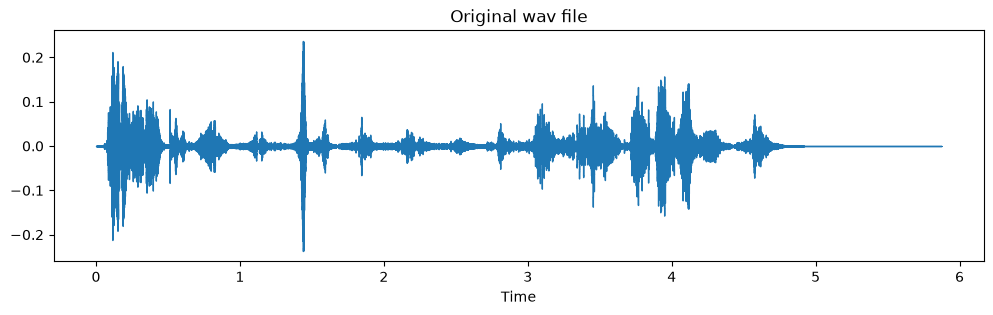

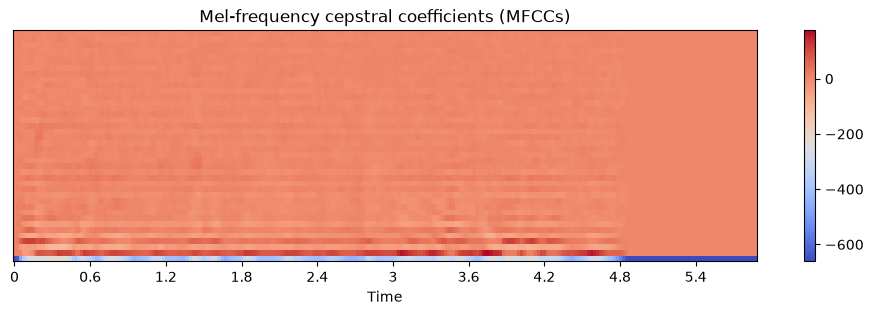

In [31]:
data_example, sampling_rate = librosa.load(sample_file)

fig1 = plt.figure(figsize=(12, 3))
librosa.display.waveshow(data_example, sr=sampling_rate)
plt.title('Original wav file')

fig2 = plt.figure(figsize=(12, 3))
mfcc = librosa.feature.mfcc(y=data_example, sr=sampling_rate, n_mfcc=40)
librosa.display.specshow(mfcc, sr=sampling_rate, x_axis='time')
plt.colorbar()
plt.title('Mel-frequency cepstral coefficients (MFCCs)');